# Preprocessing — Cat vs Dog Dataset
**Image Processing Course — Spring 2026 | Elsewedy University of Technology**

This notebook covers all required preprocessing steps for the Cat vs Dog classification task:

| Step | Description |
|---|---|
| 1 | Import Libraries & Set Paths |
| 2 | Dataset Overview & Sample Images |
| 3 | Handle Corrupted Images |
| 4 | Resize Images to 224x224 |
| 5 | Normalize Pixel Values to [0, 1] |
| 6 | Class Balance Check |
| 7 | Train / Validation / Test Split (70% / 15% / 15%) |
| 8 | Summary |

## 1. Import Libraries & Set Paths

In [1]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

BASE_DIR  = Path('../')
CATS_DIR  = BASE_DIR / 'data' / 'subset' / 'cats'
DOGS_DIR  = BASE_DIR / 'data' / 'subset' / 'dogs'
SPLIT_DIR = BASE_DIR / 'data' / 'split'
RESULTS   = BASE_DIR / 'results'

os.makedirs(RESULTS, exist_ok=True)

print('Libraries imported successfully')
print(f'Cats folder : {CATS_DIR}')
print(f'Dogs folder : {DOGS_DIR}')

Libraries imported successfully
Cats folder : ..\data\subset\cats
Dogs folder : ..\data\subset\dogs


## 2. Dataset Overview & Sample Images

We start by understanding what the dataset looks like:
- How many images per class
- What the images look like visually
- What are the original resolutions before preprocessing

The dataset is a **Natural image** dataset containing real-world photos of cats and dogs
in various poses, backgrounds, and lighting conditions.

In [2]:
cat_files = [f for f in os.listdir(CATS_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]
dog_files = [f for f in os.listdir(DOGS_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]

print('Dataset Overview:')
print(f'  Total cat images : {len(cat_files)}')
print(f'  Total dog images : {len(dog_files)}')
print(f'  Grand total      : {len(cat_files) + len(dog_files)}')

print('\nSample original resolutions:')
for f in random.sample(cat_files, 3):
    img = Image.open(CATS_DIR / f)
    print(f'  Cat: {img.size[0]}x{img.size[1]} | Mode: {img.mode}')
for f in random.sample(dog_files, 3):
    img = Image.open(DOGS_DIR / f)
    print(f'  Dog: {img.size[0]}x{img.size[1]} | Mode: {img.mode}')

Dataset Overview:
  Total cat images : 3000
  Total dog images : 3000
  Grand total      : 6000

Sample original resolutions:
  Cat: 500x375 | Mode: RGB
  Cat: 400x362 | Mode: RGB
  Cat: 325x488 | Mode: RGB
  Dog: 405x321 | Mode: RGB
  Dog: 271x238 | Mode: RGB
  Dog: 500x375 | Mode: RGB


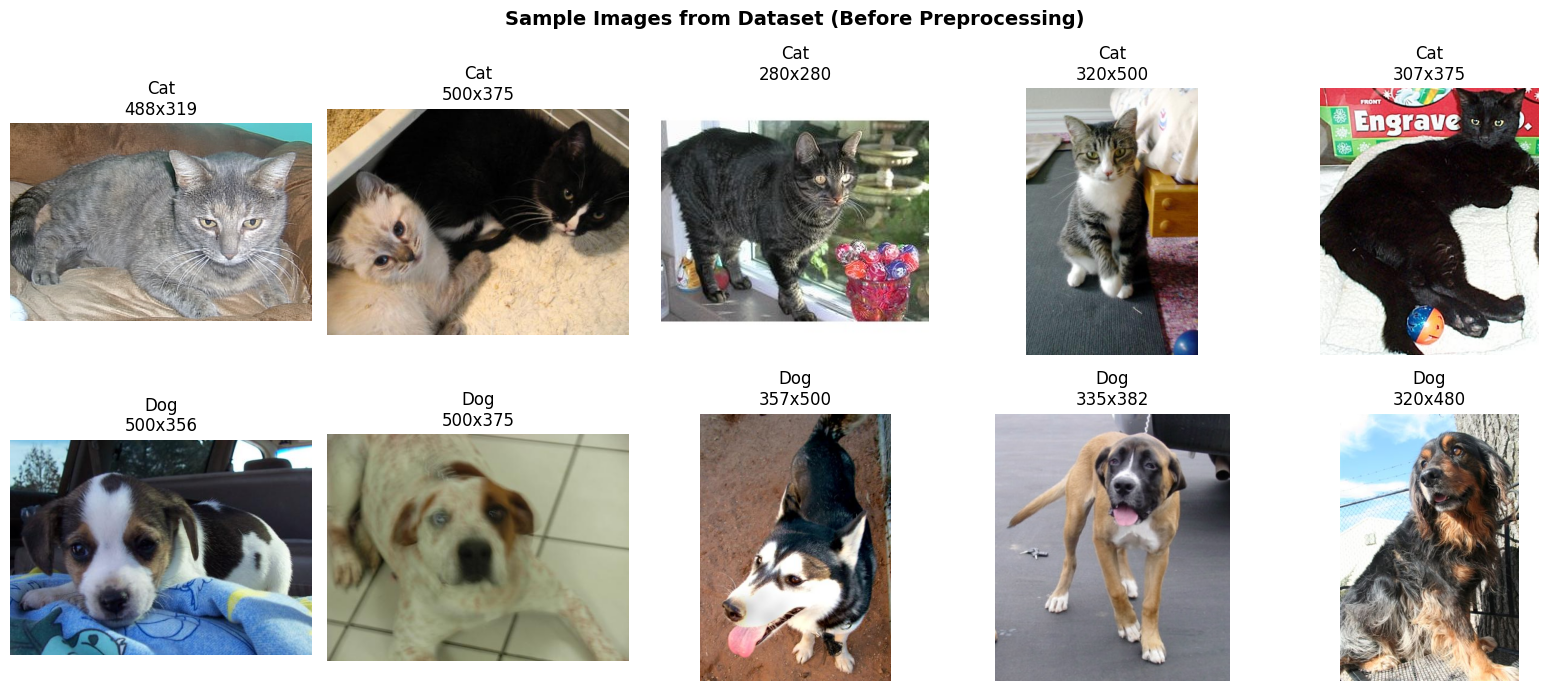

Saved: preprocessing_01_samples.png


In [3]:
random.seed(42)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Images from Dataset (Before Preprocessing)', fontsize=14, fontweight='bold')

for i, fname in enumerate(random.sample(cat_files, 5)):
    img = Image.open(CATS_DIR / fname).convert('RGB')
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Cat\n{img.size[0]}x{img.size[1]}')
    axes[0, i].axis('off')

for i, fname in enumerate(random.sample(dog_files, 5)):
    img = Image.open(DOGS_DIR / fname).convert('RGB')
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Dog\n{img.size[0]}x{img.size[1]}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(RESULTS / 'preprocessing_01_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: preprocessing_01_samples.png')

## 3. Handle Corrupted Images

Before preprocessing, we scan all images to detect and remove corrupted files.
A corrupted image is one that cannot be opened or read properly.

**Why this matters:** Corrupted images cause errors during training and must be removed before proceeding.

In [4]:
def check_corrupted(folder, files, label):
    corrupted = []
    for f in files:
        try:
            img = Image.open(folder / f)
            img.verify()
        except Exception:
            corrupted.append(f)
    print(f'  {label}: {len(files)} checked — {len(corrupted)} corrupted')
    if corrupted:
        for f in corrupted:
            os.remove(folder / f)
        print(f'  Removed {len(corrupted)} corrupted files')
    else:
        print(f'  No corrupted images found')
    return len(corrupted)

print('Scanning for corrupted images...')
corrupt_cats = check_corrupted(CATS_DIR, cat_files, 'Cats')
corrupt_dogs = check_corrupted(DOGS_DIR, dog_files, 'Dogs')
print(f'\nTotal corrupted images removed: {corrupt_cats + corrupt_dogs}')

Scanning for corrupted images...
  Cats: 3000 checked — 0 corrupted
  No corrupted images found
  Dogs: 3000 checked — 0 corrupted
  No corrupted images found

Total corrupted images removed: 0


## 4. Resize Images to 224x224

Original images have **varying resolutions** — neural networks require a **fixed input size**.
We resize all images to **224x224 pixels** using LANCZOS resampling for high quality.

All images are also converted to **RGB (3 channels)** to ensure consistency.

**Why 224x224?** This is the standard input size for most CNN architectures (VGG, ResNet, MobileNet).

> Note: Resize is applied automatically during training via `flow_from_directory(target_size=(224,224))`

Cat: 500x375 → 224x224
Dog: 327x500 → 224x224


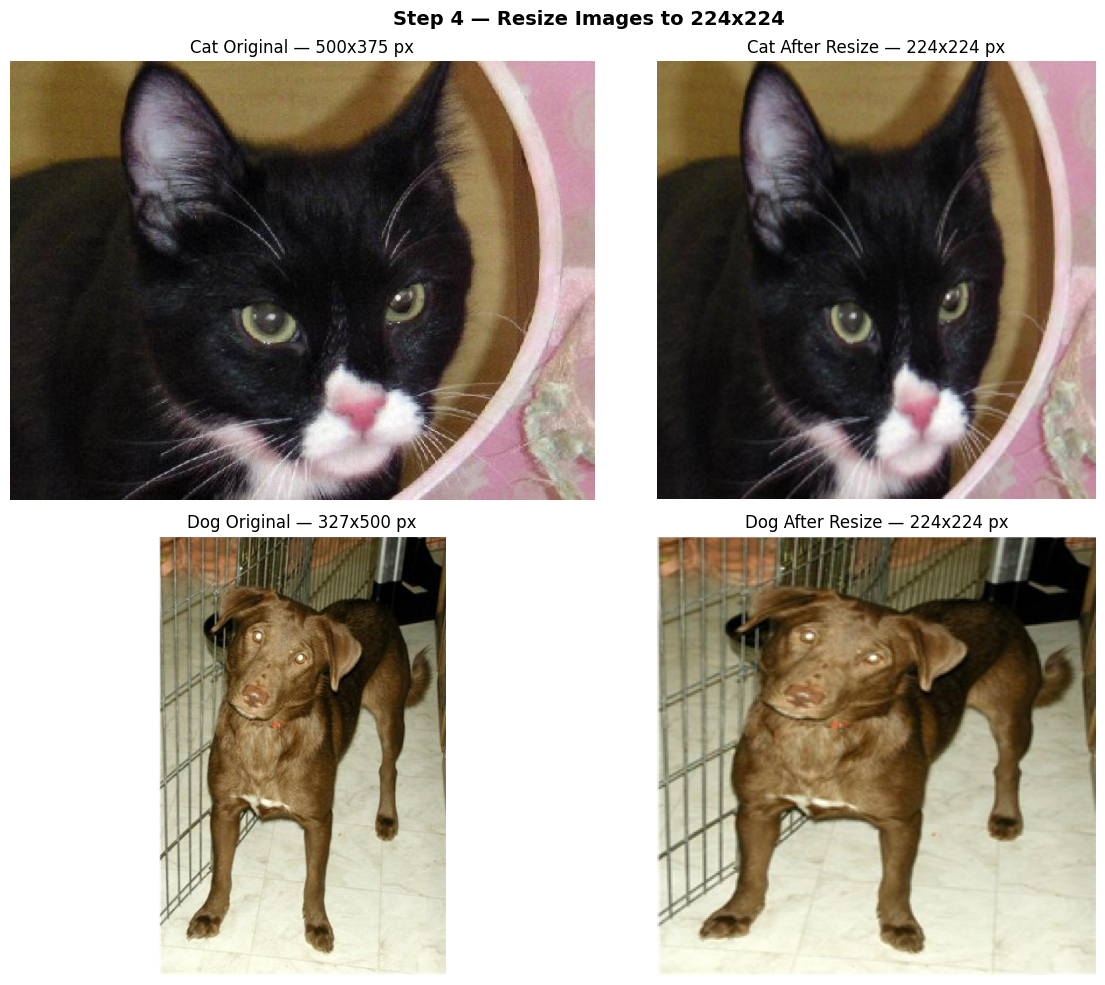

Saved: preprocessing_02_resize.png


In [5]:
TARGET_SIZE = (224, 224)

sample_cat = CATS_DIR / cat_files[0]
sample_dog = DOGS_DIR / dog_files[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Step 4 — Resize Images to 224x224', fontsize=14, fontweight='bold')

for row, (path, label) in enumerate([(sample_cat, 'Cat'), (sample_dog, 'Dog')]):
    original = Image.open(path).convert('RGB')
    resized  = original.resize(TARGET_SIZE, Image.Resampling.LANCZOS)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f'{label} Original — {original.size[0]}x{original.size[1]} px')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(resized)
    axes[row, 1].set_title(f'{label} After Resize — 224x224 px')
    axes[row, 1].axis('off')

    print(f'{label}: {original.size[0]}x{original.size[1]} → 224x224')

plt.tight_layout()
plt.savefig(RESULTS / 'preprocessing_02_resize.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: preprocessing_02_resize.png')

## 5. Normalize Pixel Values to [0, 1]

Raw images have pixel values in the range **[0, 255]**.
We normalize them to **[0.0, 1.0]** by dividing by 255.

**Why normalize?**
- Speeds up training — gradient descent converges faster
- Prevents large pixel values from dominating the learning process
- Required for stable deep learning training

**Formula:** `normalized_pixel = pixel_value / 255.0`

> Note: Normalization is applied automatically during training via `ImageDataGenerator(rescale=1./255)`

Cat — Before: min=0, max=255
Cat — After : min=0.000, max=1.000
Dog — Before: min=0, max=255
Dog — After : min=0.000, max=1.000


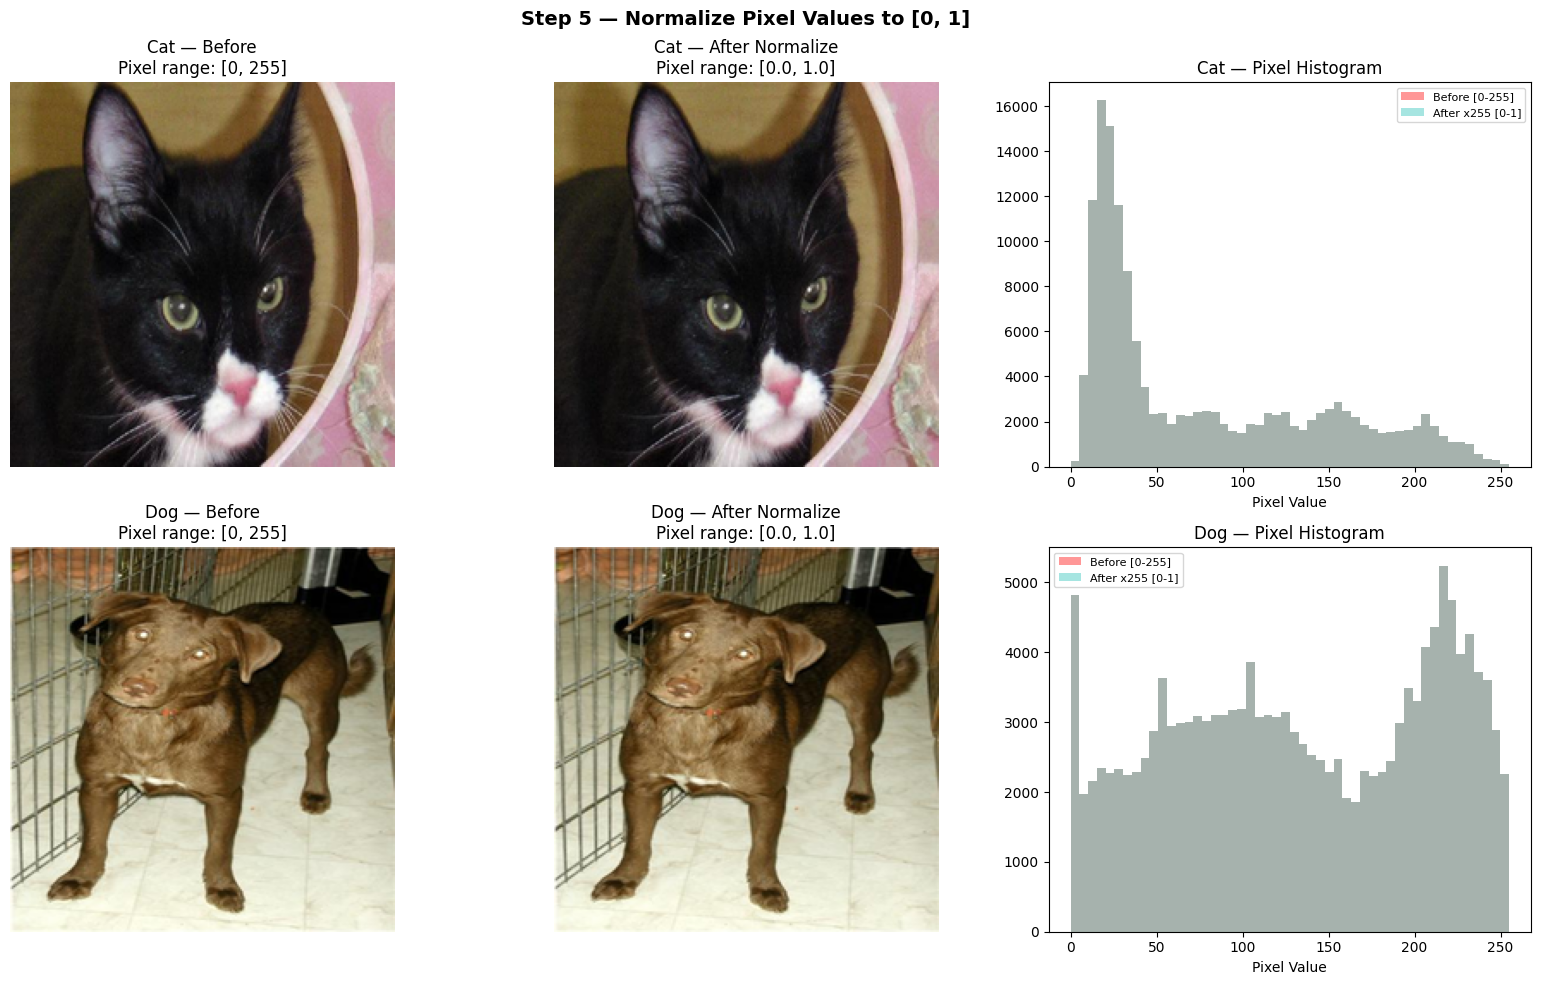

Saved: preprocessing_03_normalize.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Step 5 — Normalize Pixel Values to [0, 1]', fontsize=14, fontweight='bold')

for row, (path, label) in enumerate([(sample_cat, 'Cat'), (sample_dog, 'Dog')]):
    original  = Image.open(path).convert('RGB')
    resized   = original.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
    orig_arr  = np.array(resized)
    norm_arr  = orig_arr / 255.0

    axes[row, 0].imshow(orig_arr)
    axes[row, 0].set_title(f'{label} — Before\nPixel range: [0, 255]')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(norm_arr)
    axes[row, 1].set_title(f'{label} — After Normalize\nPixel range: [0.0, 1.0]')
    axes[row, 1].axis('off')

    axes[row, 2].hist(orig_arr.ravel(), bins=50, color='#FF6B6B', alpha=0.7, label='Before [0-255]')
    axes[row, 2].hist(norm_arr.ravel() * 255, bins=50, color='#4ECDC4', alpha=0.5, label='After x255 [0-1]')
    axes[row, 2].set_title(f'{label} — Pixel Histogram')
    axes[row, 2].set_xlabel('Pixel Value')
    axes[row, 2].legend(fontsize=8)

    print(f'{label} — Before: min={orig_arr.min()}, max={orig_arr.max()}')
    print(f'{label} — After : min={norm_arr.min():.3f}, max={norm_arr.max():.3f}')

plt.tight_layout()
plt.savefig(RESULTS / 'preprocessing_03_normalize.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: preprocessing_03_normalize.png')

## 6. Class Balance Check

We verify that the dataset is **balanced** — equal number of cats and dogs.

**Why this matters:**
- An imbalanced dataset causes the model to be biased toward the majority class
- If imbalanced, we must address it using oversampling, undersampling, or class weights

Our dataset was carefully selected to have **3,000 cats and 3,000 dogs** — perfectly balanced.

Class Balance:
  Cats : 3000 (50.0%)
  Dogs : 3000 (50.0%)
  Total: 6000

Dataset is BALANCED — no action needed


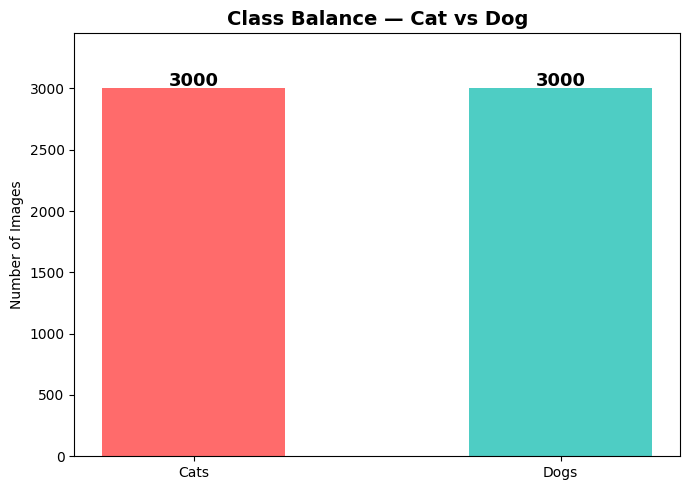

Saved: preprocessing_04_class_balance.png


In [7]:
cat_files = [f for f in os.listdir(CATS_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]
dog_files = [f for f in os.listdir(DOGS_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]

total   = len(cat_files) + len(dog_files)
cat_pct = len(cat_files) / total * 100
dog_pct = len(dog_files) / total * 100

print('Class Balance:')
print(f'  Cats : {len(cat_files)} ({cat_pct:.1f}%)')
print(f'  Dogs : {len(dog_files)} ({dog_pct:.1f}%)')
print(f'  Total: {total}')

if abs(cat_pct - dog_pct) < 5:
    print('\nDataset is BALANCED — no action needed')
else:
    print('\nDataset is IMBALANCED — needs to be addressed')

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Cats', 'Dogs'], [len(cat_files), len(dog_files)],
               color=['#FF6B6B', '#4ECDC4'], width=0.5)
for bar, count in zip(bars, [len(cat_files), len(dog_files)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', fontweight='bold', fontsize=13)
ax.set_title('Class Balance — Cat vs Dog', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_ylim([0, max(len(cat_files), len(dog_files)) * 1.15])
plt.tight_layout()
plt.savefig(RESULTS / 'preprocessing_04_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: preprocessing_04_class_balance.png')

## 7. Train / Validation / Test Split (70% / 15% / 15%)

We split the dataset into three sets:

| Split | Percentage | Purpose |
|---|---|---|
| **Train** | 70% | Used to train the model weights |
| **Validation** | 15% | Monitor performance during training, tune hyperparameters |
| **Test** | 15% | Final evaluation only after training is complete |

The split uses **stratified sampling** — each split maintains equal proportions of cats and dogs.

Images are organized into subfolders so `ImageDataGenerator.flow_from_directory()` can load
them in **batches during training** — this avoids memory errors.

In [8]:
for split in ['train', 'val', 'test']:
    for cls in ['cats', 'dogs']:
        os.makedirs(SPLIT_DIR / split / cls, exist_ok=True)

def split_and_copy(folder, files, label, train_r=0.70, val_r=0.15):
    random.seed(42)
    files = files.copy()
    random.shuffle(files)
    n         = len(files)
    train_end = int(n * train_r)
    val_end   = int(n * (train_r + val_r))
    splits = {
        'train': files[:train_end],
        'val':   files[train_end:val_end],
        'test':  files[val_end:]
    }
    for split_name, split_files in splits.items():
        for f in split_files:
            dest = SPLIT_DIR / split_name / label / f
            if not dest.exists():
                shutil.copy(folder / f, dest)
        print(f'  {split_name:6s}: {len(split_files):4d} {label}')

print('Splitting cats...')
split_and_copy(CATS_DIR, cat_files, 'cats')
print('Splitting dogs...')
split_and_copy(DOGS_DIR, dog_files, 'dogs')

train_cats = len(os.listdir(SPLIT_DIR / 'train' / 'cats'))
train_dogs = len(os.listdir(SPLIT_DIR / 'train' / 'dogs'))
val_cats   = len(os.listdir(SPLIT_DIR / 'val'   / 'cats'))
val_dogs   = len(os.listdir(SPLIT_DIR / 'val'   / 'dogs'))
test_cats  = len(os.listdir(SPLIT_DIR / 'test'  / 'cats'))
test_dogs  = len(os.listdir(SPLIT_DIR / 'test'  / 'dogs'))

print('\nSplit complete!')
print(f'  Train : {train_cats} cats + {train_dogs} dogs = {train_cats+train_dogs}')
print(f'  Val   : {val_cats} cats + {val_dogs} dogs = {val_cats+val_dogs}')
print(f'  Test  : {test_cats} cats + {test_dogs} dogs = {test_cats+test_dogs}')

Splitting cats...
  train : 2100 cats
  val   :  450 cats
  test  :  450 cats
Splitting dogs...
  train : 2100 dogs
  val   :  450 dogs
  test  :  450 dogs

Split complete!
  Train : 2100 cats + 2100 dogs = 4200
  Val   : 450 cats + 450 dogs = 900
  Test  : 450 cats + 450 dogs = 900


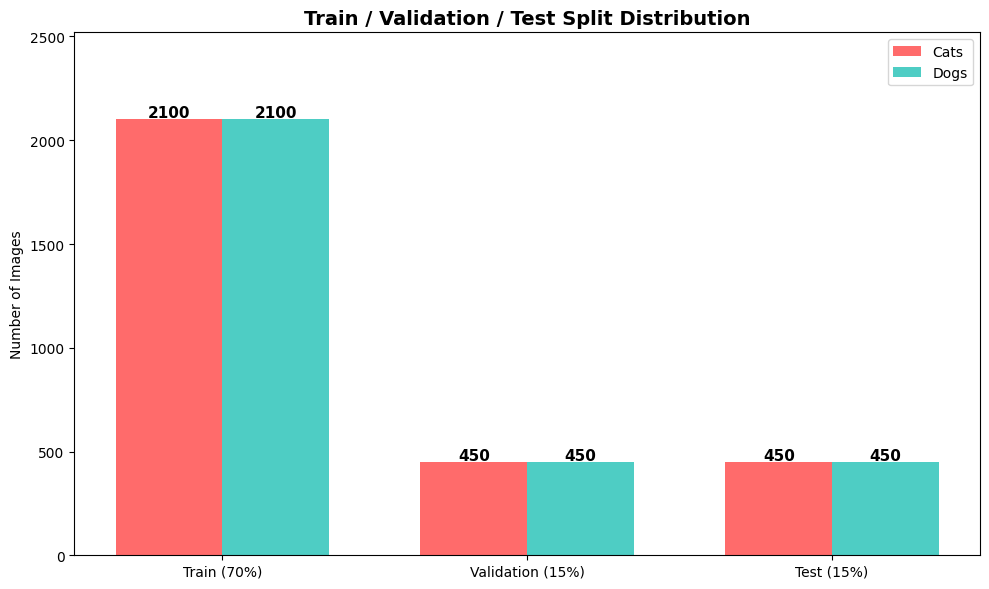

Saved: preprocessing_05_split.png


In [9]:
splits     = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
cat_counts = [train_cats, val_cats, test_cats]
dog_counts = [train_dogs, val_dogs, test_dogs]
x          = np.arange(len(splits))
width      = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, cat_counts, width, label='Cats', color='#FF6B6B')
bars2 = ax.bar(x + width/2, dog_counts, width, label='Dogs', color='#4ECDC4')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=11)

ax.set_title('Train / Validation / Test Split Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend()
ax.set_ylim([0, max(cat_counts + dog_counts) * 1.2])
plt.tight_layout()
plt.savefig(RESULTS / 'preprocessing_05_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: preprocessing_05_split.png')

## 8. Summary

All preprocessing steps have been completed successfully.
The data is now ready for model training.

In [10]:
print('=' * 60)
print('  PREPROCESSING COMPLETED SUCCESSFULLY')
print('=' * 60)
print()
print('Steps completed:')
print('  Corrupted images detected and removed')
print('  Images resized to 224x224 pixels')
print('  Pixel values normalized to [0, 1]')
print('  Class balance verified (balanced dataset)')
print('  Train / Val / Test split: 70% / 15% / 15%')
print()
print('Dataset Summary:')
print(f'  Total images   : {train_cats+train_dogs+val_cats+val_dogs+test_cats+test_dogs}')
print(f'  Train set      : {train_cats+train_dogs} images (70%)')
print(f'  Validation set : {val_cats+val_dogs} images (15%)')
print(f'  Test set       : {test_cats+test_dogs} images (15%)')
print(f'  Image size     : 224x224 pixels (RGB)')
print(f'  Pixel range    : [0.0, 1.0] after normalization')
print()
print('Charts saved to results/:')
print('  preprocessing_01_samples.png')
print('  preprocessing_02_resize.png')
print('  preprocessing_03_normalize.png')
print('  preprocessing_04_class_balance.png')
print('  preprocessing_05_split.png')
print()
print('data/split/ is ready for CNN training!')
print('=' * 60)

  PREPROCESSING COMPLETED SUCCESSFULLY

Steps completed:
  Corrupted images detected and removed
  Images resized to 224x224 pixels
  Pixel values normalized to [0, 1]
  Class balance verified (balanced dataset)
  Train / Val / Test split: 70% / 15% / 15%

Dataset Summary:
  Total images   : 6000
  Train set      : 4200 images (70%)
  Validation set : 900 images (15%)
  Test set       : 900 images (15%)
  Image size     : 224x224 pixels (RGB)
  Pixel range    : [0.0, 1.0] after normalization

Charts saved to results/:
  preprocessing_01_samples.png
  preprocessing_02_resize.png
  preprocessing_03_normalize.png
  preprocessing_04_class_balance.png
  preprocessing_05_split.png

data/split/ is ready for CNN training!
